Frame extracted at: 2.0 seconds
Reference frame selected


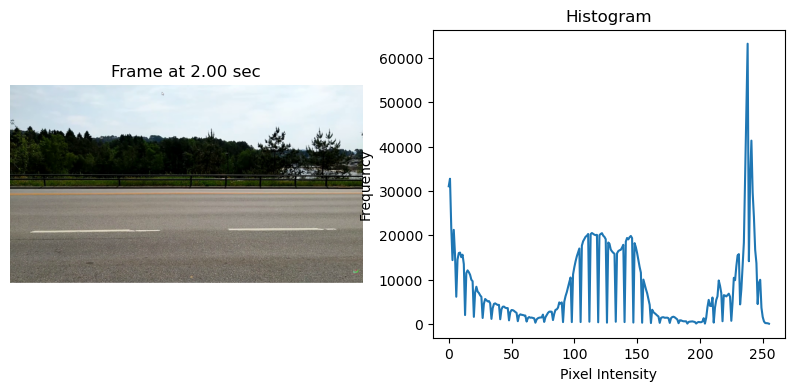

Frame extracted at: 4.0 seconds
Significant change detected


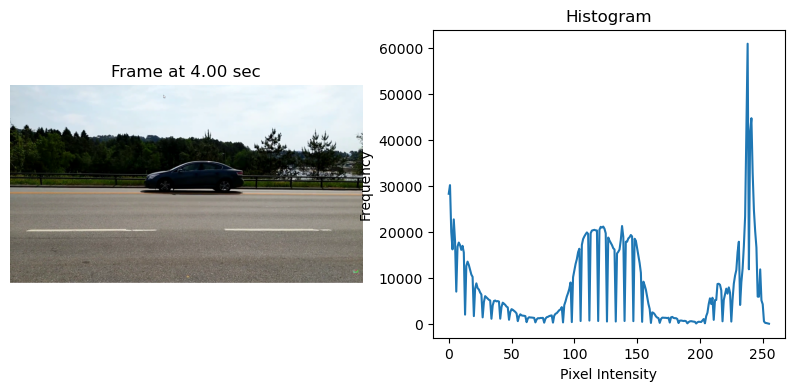

Frame extracted at: 6.0 seconds
Significant change detected


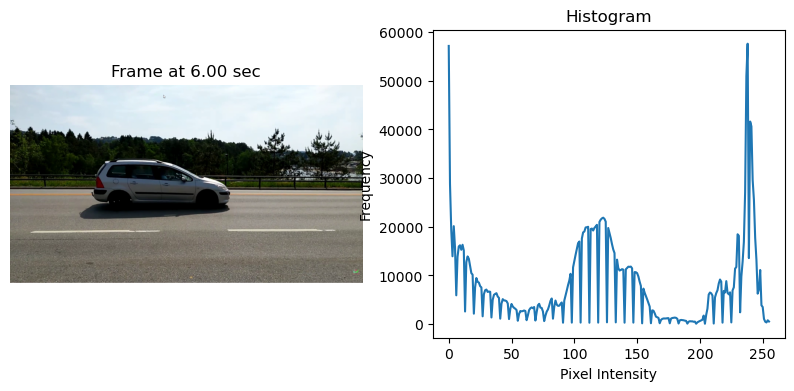

Frame extracted at: 8.0 seconds
Significant change detected


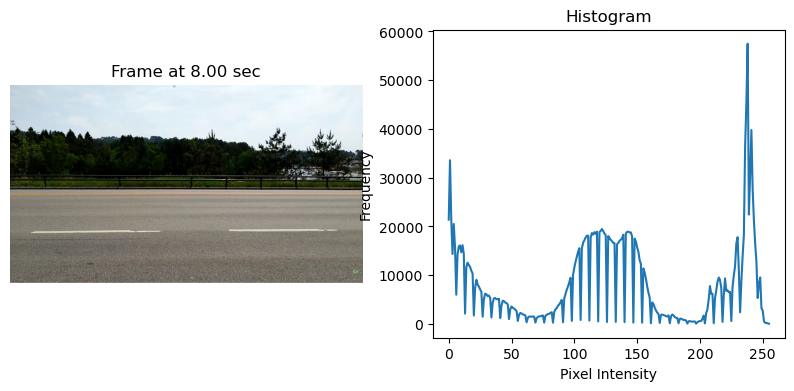

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Read video
cap = cv2.VideoCapture("car moving vid.mp4")

fps = cap.get(cv2.CAP_PROP_FPS)
interval = int(fps * 2)  # every 2 seconds

frame_count = 0
reference_hist = None

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    if frame_count % interval == 0:
        seconds = frame_count / fps

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Calculate histogram
        hist = cv2.calcHist([gray], [0], None, [256], [0, 256])

        print("Frame extracted at:", round(seconds, 2), "seconds")

        # First frame = reference frame
        if reference_hist is None:
            reference_hist = hist
            print("Reference frame selected")
        else:
            diff = cv2.compareHist(reference_hist, hist, cv2.HISTCMP_CHISQR)
            
            if diff > 5000:
                print("Significant change detected")

                # Convert BGR to RGB for matplotlib
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

                # Show frame + histogram
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.imshow(frame_rgb)
        plt.title(f"Frame at {seconds:.2f} sec")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.plot(hist)
        plt.title("Histogram")
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency")

        plt.show()

cap.release()